In [41]:
import pandas as pd 
import matplotlib.pyplot as plt 

df = pd.read_csv("data/results.csv", sep=";", encoding="utf-8-sig")

In [42]:
df.style.format({
    "recall_at_1": "{:.0%}",
    "recall_at_3": "{:.0%}",
    "mrr": "{:.4f}",
    "avg_query_ms": "{:.2f} ms"
}).background_gradient(subset=["recall_at_1", "recall_at_3"], cmap="Blues")

,model,approach,recall_at_1,recall_at_3,mrr,avg_query_ms
0,multilingual-e5-large,buyuk cok dilli,88%,94%,0.9083,78.10 ms
1,bge-m3,buyuk cok dilli,83%,90%,0.8650,82.38 ms
2,emrecan,turkce bert,83%,94%,0.8800,22.69 ms
3,selmanbaysan-trmteb,turkce bert,80%,91%,0.8500,21.50 ms
4,atasoglu-1mb,statik/distle,9%,21%,0.1383,0.17 ms
5,cohere-embed-multilingual,API tabanli(cloud),89%,97%,0.9300,7.91 ms


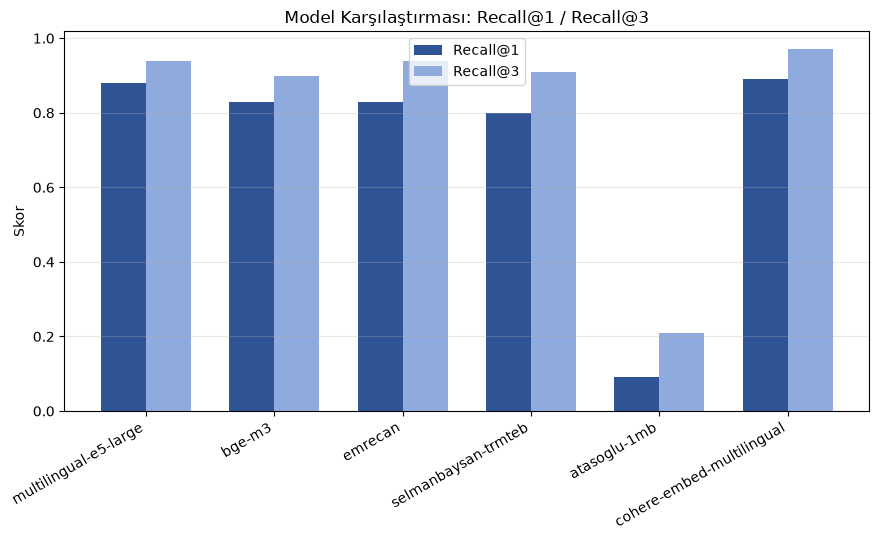

In [43]:
fig, ax = plt.subplots(figsize=(9,5.5))
x = range(len(df))
w = 0.35
ax.bar([i-w/2 for i in x], df["recall_at_1"], width=w, label="Recall@1", color="#2F5496")
ax.bar([i+w/2 for i in x], df["recall_at_3"], width=w, label="Recall@3", color="#8FAADC")
ax.set_xticks(list(x)); ax.set_xticklabels(df["model"], rotation=30, ha="right")
ax.set_ylabel("Skor")
ax.set_title("Model Karşılaştırması: Recall@1 / Recall@3")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

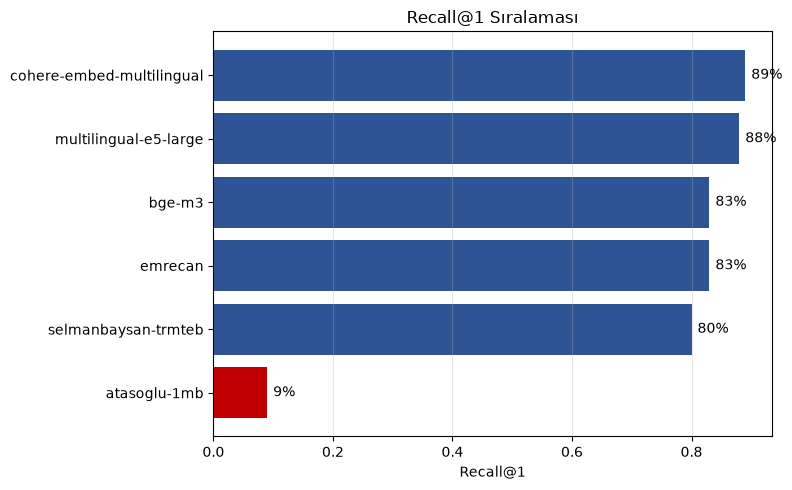

In [44]:
fig, ax = plt.subplots(figsize=(8,5))
sdf = df.sort_values("recall_at_1")
colors = ["#C00000" if v < 0.5 else "#2F5496" for v in sdf["recall_at_1"]]
ax.barh(sdf["model"], sdf["recall_at_1"], color=colors)
ax.set_xlabel("Recall@1")
ax.set_title("Recall@1 Sıralaması")
for i, v in enumerate(sdf["recall_at_1"]):
    ax.text(v+0.01, i, f"{v:.0%}", va="center")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

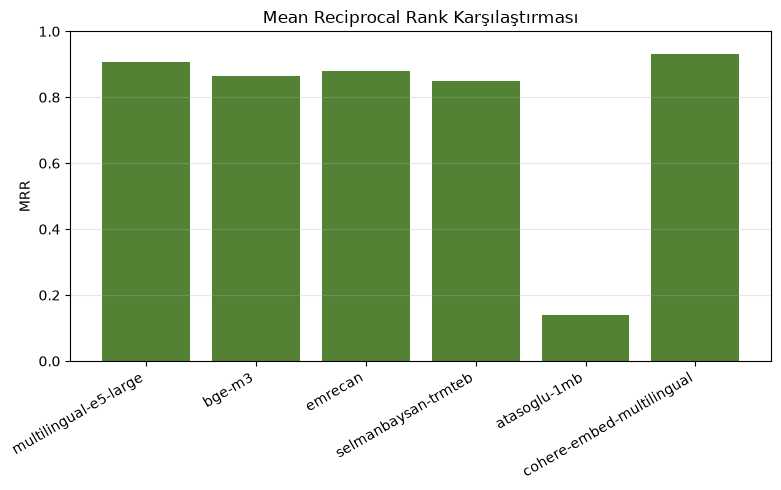

In [45]:
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(df["model"], df["mrr"], color="#548235")
ax.set_ylabel("MRR")
ax.set_title("Mean Reciprocal Rank Karşılaştırması")
ax.set_ylim(0,1)
plt.xticks(rotation=30, ha="right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [46]:
MIN_ACCURACY = 0.50
df["gecti_mi"] = df["recall_at_1"] >= MIN_ACCURACY
df_filtered = df[df["gecti_mi"]].copy()

def is_dominated(row, data):
    for _, other in data.iterrows():
        if other["model"] == row["model"]:
            continue
        faster_or_equal = other["avg_query_ms"] <= row["avg_query_ms"]
        more_or_equal_accurate = other["recall_at_1"] >= row["recall_at_1"]
        strictly_better = (other["avg_query_ms"] < row["avg_query_ms"]) or (other["recall_at_1"] > row["recall_at_1"])
        if faster_or_equal and more_or_equal_accurate and strictly_better:
            return True
    return False

df_filtered["pareto_optimal"] = ~df_filtered.apply(lambda r: is_dominated(r, df_filtered), axis=1)

print(f"=== Pareto Analizi (Recall@1 >= %{MIN_ACCURACY:.0%}) ===\n")

elenen = df[~df["gecti_mi"]]
if len(elenen) > 0:
    print("Eşik altında kaldığı için analiz dışı:")
    for _, row in elenen.iterrows():
        print(f"  {row['model']:<28} Recall@1={row['recall_at_1']:.0%}  -> ELENDİ (eşik altı)")
    print()

for _, row in df_filtered.iterrows():
    status = "Pareto-optimal" if row["pareto_optimal"] else "ELENDİ (başka model hem daha hızlı hem daha doğru)"
    print(f"{row['model']:<28} Recall@1={row['recall_at_1']:.0%}  Hız={row['avg_query_ms']:>7.2f}ms  -> {status}")

=== Pareto Analizi (Recall@1 >= %50%) ===

Eşik altında kaldığı için analiz dışı:
  atasoglu-1mb                 Recall@1=9%  -> ELENDİ (eşik altı)

multilingual-e5-large        Recall@1=88%  Hız=  78.10ms  -> ELENDİ (başka model hem daha hızlı hem daha doğru)
bge-m3                       Recall@1=83%  Hız=  82.38ms  -> ELENDİ (başka model hem daha hızlı hem daha doğru)
emrecan                      Recall@1=83%  Hız=  22.69ms  -> ELENDİ (başka model hem daha hızlı hem daha doğru)
selmanbaysan-trmteb          Recall@1=80%  Hız=  21.50ms  -> ELENDİ (başka model hem daha hızlı hem daha doğru)
cohere-embed-multilingual    Recall@1=89%  Hız=   7.91ms  -> Pareto-optimal


In [47]:
best_acc_model = df_filtered.loc[df_filtered["recall_at_1"].idxmax()]
print(f"=== '{best_acc_model['model']}' referans alınarak trade-off ===\n")

for _, row in df_filtered.iterrows():
    if row["model"] == best_acc_model["model"]:
        continue
    acc_loss_pct = (best_acc_model["recall_at_1"] - row["recall_at_1"]) / best_acc_model["recall_at_1"] * 100
    speed_gain_pct = (best_acc_model["avg_query_ms"] - row["avg_query_ms"]) / best_acc_model["avg_query_ms"] * 100
    mult = best_acc_model["avg_query_ms"] / row["avg_query_ms"] if row["avg_query_ms"] > 0 else float("inf")
    print(f"{row['model']:<28} %{acc_loss_pct:6.1f} doğruluk farkı  |  %{speed_gain_pct:6.1f} hız farkı  ({mult:.1f}x)")

=== 'cohere-embed-multilingual' referans alınarak trade-off ===

multilingual-e5-large        %   1.1 doğruluk farkı  |  %-887.4 hız farkı  (0.1x)
bge-m3                       %   6.7 doğruluk farkı  |  %-941.5 hız farkı  (0.1x)
emrecan                      %   6.7 doğruluk farkı  |  %-186.9 hız farkı  (0.3x)
selmanbaysan-trmteb          %  10.1 doğruluk farkı  |  %-171.8 hız farkı  (0.4x)


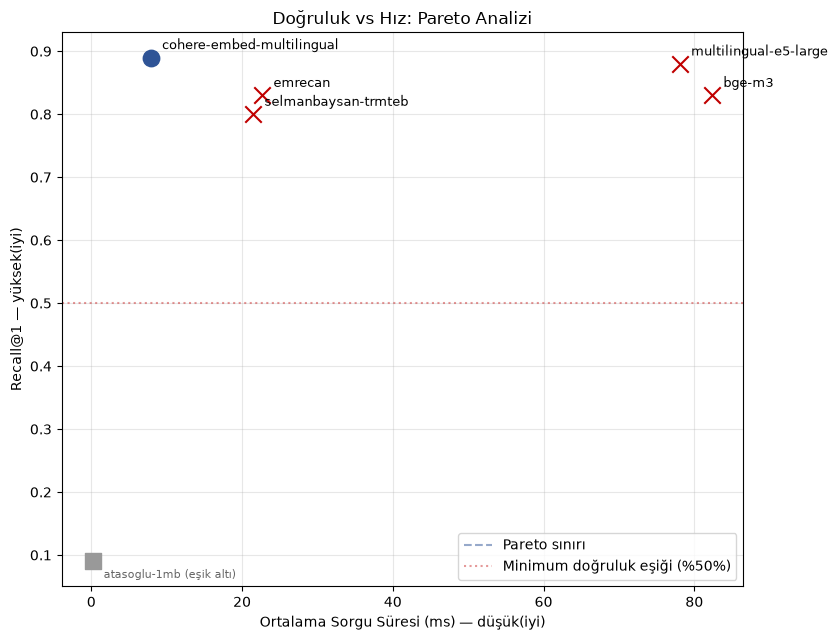

In [48]:
fig, ax = plt.subplots(figsize=(8.5,6.5))

for _, row in df_filtered.iterrows():
    color = "#2F5496" if row["pareto_optimal"] else "#C00000"
    marker = "o" if row["pareto_optimal"] else "x"
    ax.scatter(row["avg_query_ms"], row["recall_at_1"], s=140, color=color, marker=marker, zorder=3)
    ax.annotate(row["model"], (row["avg_query_ms"], row["recall_at_1"]), textcoords="offset points", xytext=(8,6), fontsize=9)

for _, row in elenen.iterrows():
    ax.scatter(row["avg_query_ms"], row["recall_at_1"], s=140, color="#999999", marker="s", zorder=2)
    ax.annotate(f"{row['model']} (eşik altı)", (row["avg_query_ms"], row["recall_at_1"]), textcoords="offset points", xytext=(8,-12), fontsize=8, color="#666666")

pareto_df = df_filtered[df_filtered["pareto_optimal"]].sort_values("avg_query_ms")
ax.plot(pareto_df["avg_query_ms"], pareto_df["recall_at_1"], "--", color="#2F5496", alpha=0.5, zorder=1, label="Pareto sınırı")
ax.axhline(MIN_ACCURACY, color="#C00000", linestyle=":", alpha=0.4, label=f"Minimum doğruluk eşiği (%{MIN_ACCURACY:.0%})")

ax.set_xlabel("Ortalama Sorgu Süresi (ms) — düşük(iyi)")
ax.set_ylabel("Recall@1 — yüksek(iyi)")
ax.set_title("Doğruluk vs Hız: Pareto Analizi")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("outputs/pareto.png", dpi=140)
plt.show()